# Kaggle - Brain Tumor MRI Dataset

You can find the dataset and some informations about on the [Kaggle page](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset).

For details on steps below, please see documentation in the *docs* directory.

## Kaggle notebook setup
### Installations

In [1]:
!pip install mlflow --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 87.0 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 95.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 69.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.2/131.2 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 797.8/797.8 kB 47.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.5/66.5 kB 4.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour 

### Data location

In [2]:
import os
print(os.listdir('/kaggle/input/'))
print(os.listdir('/kaggle/input/radimagenet-densenet121-notop'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed'))
print(os.listdir('/kaggle/input/brain-tumor-mri-preprocessed/processed'))
print(os.listdir('/kaggle/input/brain-tumor-heads-weights'))

['radimagenet-densenet121-notop', 'brain-tumor-heads-weights', 'brain-tumor-mri-preprocessed']
['RadImageNet-DenseNet121_notop.h5']
['processed']
['Validation', 'Training', 'Testing', '.gitkeep']
['brain_tumor_heads.weights.h5']


## General

In [3]:
import mlflow
import mlflow.tensorflow
from mlflow.tracking import MlflowClient
mlflow.set_tracking_uri("https://preachingly-nonabjuratory-marget.ngrok-free.dev")
mlflow.set_experiment("Brain_Tumor_Training")

2026-02-11 10:34:58.027563: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770806098.195985      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770806098.248975      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770806098.659681      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770806098.659728      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770806098.659730      55 computation_placer.cc:177] computation placer alr

<Experiment: artifact_location='mlflow-artifacts:/830660600119881173', creation_time=1769099937797, experiment_id='830660600119881173', last_update_time=1769099937797, lifecycle_stage='active', name='Brain_Tumor_Training', tags={'mlflow.experimentKind': 'custom_model_development'}>

In [4]:
import numpy as np

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from datetime import datetime
import math

import cv2
from collections import defaultdict

In [5]:
tf.keras.mixed_precision.set_global_policy("mixed_float16")
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
tf.config.list_physical_devices('GPU')

Num GPUs Available: 1


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [6]:
# path management
PROJECT_ROOT = '/kaggle/input'
PREP_DIR = PROJECT_ROOT + '/brain-tumor-mri-preprocessed/processed'
ARTEFACTS_DIR = PROJECT_ROOT + '/radimagenet-densenet121-notop'
BEST_HEAD_DIR = PROJECT_ROOT + '/brain-tumor-heads-weights'
OUTPUT_DIR = "kaggle/working/radcam_results"
os.makedirs(OUTPUT_DIR + "/correct", exist_ok=True)
os.makedirs(OUTPUT_DIR + "/errors", exist_ok=True)

CHECKPOINT_DIR = "/kaggle/working/checkpoints"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
MODEL_DIR = "/kaggle/working/export_model"
os.makedirs(MODEL_DIR, exist_ok=True)

CLASSES = ["notumor", "glioma", "meningioma", "pituitary"]

# model parameters
IMG_SIZE = 260
SEED = 42

PROJECT_NAME = "BrainTumorMRI"
MODEL_TYPE = "DenseNet121"
TWO_HEAD = True
MODEL_NAME = f"{PROJECT_NAME}_{MODEL_TYPE}_{TWO_HEAD*"2Head"}"
FREEZE_BACKBONE = True
MASK_TUMOR_TYPE_LOSS = True
BATCH_SIZE = 32
DATA_AUGMENTATION = True

## Modeling

### Backbone

In [7]:
def get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    # 1. Create DenseNet121 WITHOUT weights
    backbone = DenseNet121(
        include_top=False,
        weights=None,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    
    # 2. Load RadImageNet weights
    backbone.load_weights(ARTEFACTS_DIR + "/RadImageNet-DenseNet121_notop.h5")
    
    # 3. Freeze the backbone for firsts training
    backbone.trainable = not FREEZE_BACKBONE
    
    print("✅ RadImageNet DenseNet121 loaded successfully")
    
    return backbone

In [8]:
backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)

I0000 00:00:1770806112.703228      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


✅ RadImageNet DenseNet121 loaded successfully


In [9]:
#backbone.summary()

In [10]:
w = backbone.weights[0].numpy()
print("Mean:", np.mean(w), "Std:", np.std(w))

Mean: -0.0028284893 Std: 0.10494729


Model seems to be correctly loaded.

### Model definition

In [11]:
def get_model_data_augmentation():
    return keras.Sequential([
        layers.RandomFlip("horizontal", seed=SEED),
        layers.RandomZoom((-0.03,0.03),(-0.03,0.03), seed=SEED),
        layers.RandomTranslation((-0.01,0.01),(-0.01,0.01), seed=SEED),
    ], name='data_augmentation_part')

In [12]:
def get_model_head_presence():
    return keras.Sequential([
        layers.Dense(128, use_bias=False), 
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        layers.Dense(1,activation='sigmoid')
    ], name='tumor_presence')

In [13]:
def get_model_head_type():
    return keras.Sequential([
        layers.Dense(128, use_bias=False), 
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.2),
        layers.Dense(4,activation='softmax')
    ], name='tumor_type')

In [14]:
def shared_head_part(inputs, backbone, data_augmentation=None):
    # Data augmentation (training only)
    x = data_augmentation(inputs)
    # Backbone - force into inference
    #x = backbone(x, training=False)
    x = backbone(x)

    # Shared head
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.4)(x)

    return x

In [15]:
def assemble_heads(IMG_SIZE, backbone, model_data_augmentation, model_head1, model_head2):
    inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    
    x = shared_head_part(inputs, backbone, model_data_augmentation)
    
    #Heads
    output_presence = model_head1(x)
    output_type = model_head2(x)
    
    model = keras.Model(
        inputs=inputs,
        outputs={
            "tumor_presence": output_presence,
            "tumor_type": output_type
        },
        name='densenet_two_head'
    )

    return model

In [16]:
def get_loss_presence():
    return keras.losses.BinaryFocalCrossentropy(
        gamma=2.0,
        alpha=0.25 # to favorize tumor detection (penalize false negatives), but taking account that tumors are 75% of data
    )

In [17]:
#@keras.saving.register_keras_serializable()
@tf.keras.utils.register_keras_serializable()
def masked_sparse_cce(y_true, y_pred):
    tumor_present = tf.cast(y_true != 0, tf.float32)
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
    loss = loss * tumor_present
    return tf.reduce_sum(loss) / (tf.reduce_sum(tumor_present) + 1e-6)

In [18]:
def compile_model(model, masked_sparse_cce):
    loss_presence = get_loss_presence()
    
    loss_weight_presence = 1.0
    loss_weight_type = 1.3 # we give a little more weight to the classification of the type
    
    model.compile(
        optimizer=keras.optimizers.Adam(), # change learning_rate for 1e-4 in fine-tuning steps
        loss={
            "tumor_presence": loss_presence,
            "tumor_type": masked_sparse_cce,
        },
        
        loss_weights={
            "tumor_presence": loss_weight_presence,
            "tumor_type": loss_weight_type, 
        },
        
        metrics={
            "tumor_presence": [
                keras.metrics.BinaryAccuracy(name="accuracy"),
                keras.metrics.Recall(name="recall"),
                keras.metrics.Precision(name="precision"),
                #keras.metrics.F1Score(name="f1_score"),
                keras.metrics.AUC(name="auc")
            ],
            "tumor_type": [
                "accuracy", 
                #"f1_score"
            ],
        }
    )

    return model

In [19]:
def get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE):
    
    backbone = get_backbone(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
    model_data_augmentation = get_model_data_augmentation()
    model_head1 = get_model_head_presence()
    model_head2 = get_model_head_type()
    model = assemble_heads(IMG_SIZE, backbone, model_data_augmentation, model_head1, model_head2)

    return model

In [20]:
model = get_model_built(IMG_SIZE, ARTEFACTS_DIR, FREEZE_BACKBONE)
model = compile_model(model, masked_sparse_cce)

✅ RadImageNet DenseNet121 loaded successfully


In [21]:
#model.summary()

## Streaming Training

In [22]:
def parse_tfrecord(example_proto):
    """
    Parse a single TFRecord example and convert grayscale → RGB.
    """
    feature_description = {
        "image": tf.io.FixedLenFeature([], tf.string),
        "label": tf.io.FixedLenFeature([], tf.int64),
    }

    example = tf.io.parse_single_example(example_proto, feature_description)

    # Deserialize image
    image = tf.io.parse_tensor(example["image"], out_type=tf.float32)

    # Shape after loading: (260, 260, 3)
    image.set_shape((260, 260, 3))

    label = tf.cast(example["label"], tf.int32)

    return image, label



def load_tfrecord_dataset(tfrecord_dir, shuffle=False, batch_size=1, repeat=False):
    """
    Load a TFRecord dataset from a directory.

    Args:
        tfrecord_dir (str or Path): Folder containing .tfrecord files
        shuffle (bool): Whether to shuffle files and samples
        batch_size (int): Batch size (can stay 1)
        repeat (bool): Repeat dataset indefinitely (for training)

    Returns:
        tf.data.Dataset
    """
    tfrecord_files = tf.io.gfile.glob(
        str(tfrecord_dir) + "/*.tfrecord"
    )

    ds = tf.data.TFRecordDataset(
        tfrecord_files,
        num_parallel_reads=tf.data.AUTOTUNE
    )

    ds = ds.map(
        parse_tfrecord,
        num_parallel_calls=tf.data.AUTOTUNE
    )

    if shuffle:
        ds = ds.shuffle(buffer_size=512)

    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


In [23]:
TRAIN_DIR = PREP_DIR + "/Training"
VAL_DIR   = PREP_DIR + "/Validation"
TEST_DIR  = PREP_DIR + "/Testing"

train_ds = load_tfrecord_dataset(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

val_ds = load_tfrecord_dataset(
    VAL_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)

"""
test_ds = load_tfrecord_dataset(
    TEST_DIR,
    shuffle=False,
    batch_size=BATCH_SIZE,
    repeat=False
).prefetch(tf.data.AUTOTUNE)
"""

'\ntest_ds = load_tfrecord_dataset(\n    TEST_DIR,\n    shuffle=False,\n    batch_size=BATCH_SIZE,\n    repeat=False\n).prefetch(tf.data.AUTOTUNE)\n'

In [24]:
def split_labels(image, label):
    """
    Create labels for a 2-head model.
    """
    tumor_present = tf.cast(label != 0, tf.float32)
    tumor_type = tf.cast(label, tf.int32)

    return image, {
        "tumor_presence": tumor_present,
        "tumor_type": tumor_type
    }


In [25]:
train_ds = train_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.map(split_labels, num_parallel_calls=tf.data.AUTOTUNE)

In [26]:
#for x, y in train_ds.take(1):
#    print("Image:")
#    print(x.dtype, x.shape)
#    print("\nLabels:")
#    for k, v in y.items():
#        print(k, v.dtype, v.shape)

In [27]:
def count_tfrecord_batches(directory_path, batch_size):
    """
    Count number of batches for a TFRecord dataset.

    Assumes:
    - 1 sample per TFRecord
    - batch_size is variable

    Returns:
    - number of batches = ceil(num_samples / batch_size)
    """
    directory_path = Path(directory_path)
    n_samples = len(list(directory_path.glob("*.tfrecord")))
    return math.ceil(n_samples / batch_size)


In [28]:
print(train_ds.element_spec)

(TensorSpec(shape=(None, 260, 260, 3), dtype=tf.float32, name=None), {'tumor_presence': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'tumor_type': TensorSpec(shape=(None,), dtype=tf.int32, name=None)})


In [29]:
#to_monitor = "val_tumor_presence_recall"
#mode = "max"
to_monitor = "val_tumor_type_loss"
mode = "min"

reduce_lr = ReduceLROnPlateau(
    monitor=to_monitor,
    mode=mode,
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

early_stopping = EarlyStopping(
    monitor=to_monitor,
    mode=mode,
    min_delta=0.0001,
    patience=10,
    restore_best_weights=False,
    verbose=1,
)

checkpoint_cb = keras.callbacks.ModelCheckpoint(
    filepath=CHECKPOINT_DIR + "/epoch_{epoch:02d}.weights.h5",
    monitor=to_monitor,
    mode=mode,
    save_best_only=False,
    save_weights_only=True,
    verbose=1,
)

terminate_nan = keras.callbacks.TerminateOnNaN()

In [30]:
#print("RUN_NAME:", RUN_NAME)
#print("TRAIN steps:", count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE))
#print("VAL steps:", count_tfrecord_batches(VAL_DIR, BATCH_SIZE))
#print("train_ds element_spec:", train_ds.element_spec)

In [31]:
raise Exception("Do not fit from scratch again. Use the best head model !")

RUN_NAME = (
    f"{MODEL_TYPE}"
    f"freeze={FREEZE_BACKBONE}_"
    f"mask={MASK_TUMOR_TYPE_LOSS}_"
    f"{datetime.now().strftime('%Y%m%d-%H%M')}"
)

print(f"Run name: {RUN_NAME}\n")

with mlflow.start_run(run_name=RUN_NAME):

    mlflow.tensorflow.autolog(registered_model_name=MODEL_NAME)

    mlflow.log_params({
        "project": PROJECT_NAME,
        "model_type": MODEL_TYPE,
        "pretrained_weights": "RadImageNet",
        "backbone_frozen": FREEZE_BACKBONE,
        "head_1": "tumor_presence_binary",
        "head_2": "tumor_type_softmax",
        "loss_weight_presence": loss_weight_presence,
        "loss_weight_type": loss_weight_type,
        "mask_tumor_type_loss": MASK_TUMOR_TYPE_LOSS,
        "label_0_means": "no_tumor",
        "data_augmentation": DATA_AUGMENTATION,
    })

    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=60,
        #steps_per_epoch=count_tfrecord_batches(TRAIN_DIR, BATCH_SIZE),
        #validation_steps=count_tfrecord_batches(VAL_DIR, BATCH_SIZE),
        callbacks=[reduce_lr, early_stopping, checkpoint_cb, terminate_nan],
        verbose=1,
    )

    client = MlflowClient()
    latest_version = client.get_latest_versions(MODEL_NAME)[-1].version

    client.transition_model_version_stage(
        name=MODEL_NAME,
        version=latest_version,
        stage="Staging"
    )


Exception: Do not fit from scratch again. Use the best head model !

## Epoch filter

In [ ]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = history_df.index
#history_df.head(5)

In [ ]:
metrics_cols = [
    "epoch",
    "val_tumor_presence_recall",
    "val_tumor_type_accuracy",
    "val_tumor_presence_loss",
    "val_tumor_type_loss"
]

df = history_df[metrics_cols].copy()

In [ ]:
df = df[
    (df["val_tumor_presence_recall"] >= 0.94) &
    (df["val_tumor_type_accuracy"] >= 0.55)
]
#df

In [ ]:
def normalize(col):
    return (col - col.min()) / (col.max() - col.min() + 1e-8)

df["pres_rec_norm"] = normalize(df["val_tumor_presence_recall"])
df["type_accu_norm"] = normalize(df["val_tumor_type_accuracy"])
df["pres_loss_norm"] = 1 - normalize(df["val_tumor_presence_loss"])
df["type_loss_norm"] = 1 - normalize(df["val_tumor_type_loss"])

In [ ]:
df["S"] = (
    0.40 * df["pres_rec_norm"]
  + 0.35 * df["type_accu_norm"]
  + 0.15 * df["pres_loss_norm"]
  + 0.10 * df["type_loss_norm"]
)
#df

In [ ]:
best_row = df.sort_values("S", ascending=False).iloc[0]
best_epoch = int(best_row["epoch"])

print(f"✅ Best epoch selected from S: {best_epoch}")
print(best_row)

In [ ]:
mlflow.set_tags({
    "model_stage": "best_manual_epoch",
    "best_epoch": best_epoch,
    "selection_method": "composite_score_S",
})

mlflow.log_metric("S", best_row.iloc[-1])
mlflow.log_metric("Best epoch", best_row.iloc[0])

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.load_weights(f"{CHECKPOINT_DIR}/epoch_{best_epoch:02d}.weights.h5")
print(f"✅ Loaded best epoch: {best_epoch}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
mlflow.tensorflow.log_model(
    model,
    name=f"best_epoch_{best_epoch}_manual",
    registered_model_name=MODEL_NAME
)
print(f"✅ Registered best model: {MODEL_NAME}")

In [ ]:
raise Exception("Do not fit from scratch again. Use the best head model !")
model.save(f"{MODEL_DIR}/brain_tumor_model_best_epoch_{best_epoch}.keras")
model.save_weights(
    f"{MODEL_DIR}/brain_tumor_weights_epoch_{best_epoch}.weights.h5"
)
mlflow.log_artifacts(MODEL_DIR, artifact_path="exported_model_files")

### Loading final model from MLFlow

In [ ]:
#model = mlflow.tensorflow.load_model(
#    "models:/BrainTumorMRI_DenseNet121_2Head/latest"
#)
#print("✅ Model loaded successfully with custom loss")

In [41]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [42]:
model = compile_model(model, masked_sparse_cce)
model.evaluate(val_ds)

36/36 ━━━━━━━━━━━━━━━━━━━━ 20s 180ms/step - loss: 0.3289 - tumor_presence_accuracy: 0.9850 - tumor_presence_auc: 0.9958 - tumor_presence_loss: 0.0168 - tumor_presence_precision: 0.9880 - tumor_presence_recall: 0.9916 - tumor_type_accuracy: 0.6632 - tumor_type_loss: 0.2400


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.3676888942718506,
 0.017765367403626442,
 0.2637573480606079,
 0.9816272854804993,
 0.9955679774284363,
 0.9890377521514893,
 0.9854369163513184,
 0.6342957019805908]

## Head control and explicability

### Confusion Matrix

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

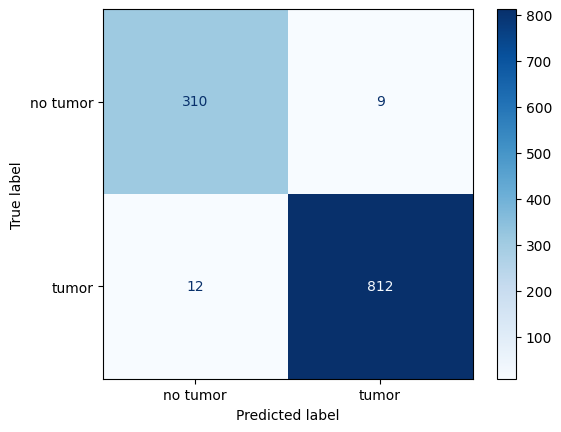

In [43]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch["tumor_presence"].numpy().astype(int).flatten())
    y_pred_type.extend((preds['tumor_presence'] > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["no tumor", "tumor"])
disp.plot(cmap='Blues')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

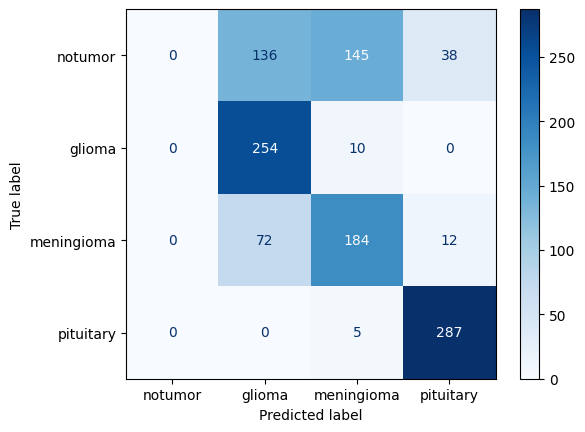

In [44]:
# Predictions on val_ds
y_true_type = []
y_pred_type = []

for x_batch, y_batch in val_ds:
    preds = model.predict(x_batch)
    y_true_type.extend(y_batch['tumor_type'].numpy())
    y_pred_type.extend(preds['tumor_type'].argmax(axis=-1))

cm = confusion_matrix(y_true_type, y_pred_type)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap='Blues')

### Grad-CAM

In [32]:
# grad-cam parameters
LAST_CONV_LAYER = "conv5_block16_2_conv"
BACKBONE_NAME = "densenet121"

In [33]:
model = get_model_built(
    IMG_SIZE,
    ARTEFACTS_DIR,
    FREEZE_BACKBONE=False
)

model.load_weights(BEST_HEAD_DIR + "/brain_tumor_heads.weights.h5")

print("✅ Model reconstructed + weights loaded")

✅ RadImageNet DenseNet121 loaded successfully
✅ Model reconstructed + weights loaded


In [34]:
def make_gradcam_plus_plus_multihead(model, img_array, backbone_name, last_conv_layer, head_name="tumor_presence", class_index=None):
    """
    Grad-CAM++ for the multi-head model (tumor_presence & tumor_type).
    Works with a nested DenseNet backbone.
    
    Args:
        model: the complete Keras model (densenet_two_head)
        img_array: image (or batch) numpy / tf.Tensor of shape (1, H, W, 3)
        head_name: “tumor_presence” or ‘tumor_type’
        class_index: int, only required if head_name==“tumor_type”
        
    Returns:
        heatmap: numpy array (H_feature, W_feature)
    """
    
    img_tensor = tf.cast(img_array, tf.float32)
    
    # --- 1️⃣ We recover the backbone and the last conv layer.
    backbone = model.get_layer(backbone_name)
    
    gradcam_backbone = tf.keras.models.Model(
        inputs=backbone.input,
        outputs=backbone.get_layer(last_conv_layer).output
    )
    
    # --- 2️⃣ Forward pass et Grad-CAM++
    with tf.GradientTape() as tape:
        # Extract conv features
        conv_outputs = gradcam_backbone(img_tensor, training=False)  # shape (1, H, W, C)
        tape.watch(conv_outputs)
        
        # Shared head
        x = layers.GlobalAveragePooling2D()(conv_outputs)
        x = layers.Dense(512, use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.Dropout(0.4)(x)
        
        # Select the head
        if head_name == "tumor_presence":
            preds = model.get_layer("tumor_presence")(x)
            loss = preds[:,0]
        elif head_name == "tumor_type":
            if class_index is None:
                raise ValueError("class_index must be specified for tumor_type head")
            preds = model.get_layer("tumor_type")(x)
            loss = preds[:, class_index]
        else:
            raise ValueError("head_name must be 'tumor_presence' or 'tumor_type'")
    
    # --- 3️⃣ Grad-CAM++ computation
    grads = tape.gradient(loss, conv_outputs)
    weights = tf.reduce_mean(grads, axis=(1,2))  # global average over HxW
    cam = tf.reduce_sum(weights[:, None, None, :] * conv_outputs, axis=-1)
    
    heatmap = tf.maximum(cam, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    
    return heatmap[0].numpy()


In [67]:
def overlay_heatmap_on_image(orig_img, heatmap, alpha=0.4):

    # --- secure heatmap ---
    heatmap = tf.convert_to_tensor(heatmap, dtype=tf.float32)

    # delete NaN / Inf
    heatmap = tf.where(tf.math.is_finite(heatmap), heatmap, 0.0)

    # normalize
    max_val = tf.reduce_max(heatmap)
    heatmap = tf.cond(
        max_val > 0,
        lambda: heatmap / max_val,
        lambda: heatmap
    )

    # add dimensions batch + channel
    heatmap = heatmap[tf.newaxis, ..., tf.newaxis]

    # resize via TF (stable)
    heatmap = tf.image.resize(
        heatmap,
        (orig_img.shape[0], orig_img.shape[1])
    )[0, ..., 0]

    # colormap matplotlib
    cmap = plt.get_cmap("jet")
    heatmap_color = cmap(heatmap.numpy())[:, :, :3]

    # image originale
    orig_img = np.array(orig_img).astype("float32")
    if orig_img.max() <= 1:
        orig_img *= 255.0

    orig_img /= 255.0

    # overlay
    superposed = (1-alpha)*orig_img + alpha*heatmap_color
    superposed = np.clip(superposed,0,1)

    return superposed

In [74]:
idx = 1092
count = 0

for x_batch, y_batch in val_ds:
    for i in range(len(x_batch)):
        if count == idx:
            test_img = x_batch[i:i+1]
            break
        count += 1

In [75]:
#test_img = next(iter(val_ds))[0][0:1]

heatmap = make_gradcam_plus_plus_multihead(
    model,
    test_img,
    BACKBONE_NAME,
    LAST_CONV_LAYER,
    head_name="tumor_presence"
)

print("✅ GradCAM++ OK")
print(heatmap.shape)


✅ GradCAM++ OK
(8, 8)


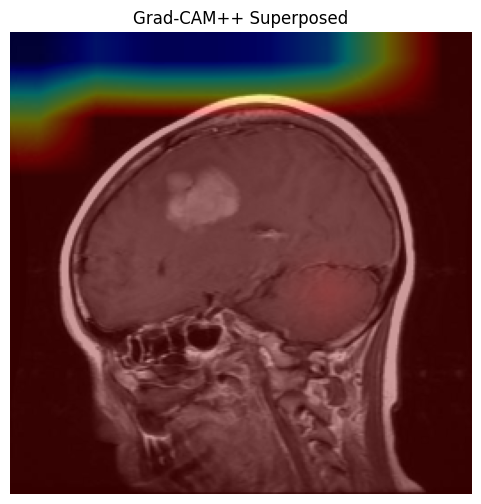

In [76]:
# --- Exemple d'utilisation ---
orig_img = test_img[0].numpy()  # tf.Tensor -> numpy
orig_img = orig_img.astype("float32")
orig_img -= orig_img.min()
orig_img /= (orig_img.max() + 1e-8)
orig_img = (orig_img * 255).astype("uint8")

superposed = overlay_heatmap_on_image(orig_img, heatmap)

plt.figure(figsize=(6,6))
plt.imshow(superposed[..., ::-1])  
plt.axis('off')
plt.title("Grad-CAM++ Superposed")
plt.show()

### Grad-CAM for confusion matrix categories

## Fine-Tuning

In [40]:
Warning : do not forget :
- GradCAM sur faux positifs
- GradCAM sur faux négatifs
- stratégie de fine-tuning du backbone
- BatchNormalization precaution in fine-tuning

SyntaxError: invalid syntax (2811355060.py, line 1)